# Project Title & Objective
Early Detection of Heart Disease Risk Using Machine Learning Classification Models
Objective: compare baseline and ensemble models, evaluate with cross-validation, and interpret feature importance.

**Explanation:** Import core libraries for data handling, visualization, and modeling. Define global constants for reproducibility and dataset metadata. Try importing optional packages (xgboost, shap) and set flags so later cells can adapt gracefully. Configure plotting defaults and warning filters to keep outputs clean and consistent.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, confusion_matrix, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "heart.csv"
DATASET_SOURCE = "Kaggle - Heart Disease Dataset"
DATASET_LINK = "https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset"

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


# Dataset Loading & Description


**Explanation:** Configure Kaggle API credentials and ensure the Kaggle CLI is available for automatic downloads. The credentials are written to `~/.kaggle/kaggle.json` with secure file permissions. The dataset is downloaded and unzipped only if `heart.csv` is missing, making the cell safe to rerun. Remove or rotate these credentials before sharing the notebook.


In [2]:
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys

KAGGLE_USERNAME = "damlayagmuryildiz"
KAGGLE_KEY = "feda447a3f20c6f946b442d748690f9f"

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_json.write_text(
    json.dumps({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}),
    encoding="utf-8",
)
os.chmod(kaggle_json, 0o600)

if shutil.which("kaggle") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])

dataset_slug = "johnsmith88/heart-disease-dataset"
if not Path(DATA_PATH).exists():
    subprocess.check_call(
        ["kaggle", "datasets", "download", "-d", dataset_slug, "-p", ".", "--unzip"]
    )
    print("Downloaded dataset.")
else:
    print("Dataset already present:", DATA_PATH)


Dataset already present: heart.csv


**Explanation:** Load the CSV dataset into a DataFrame and validate the structure. Display the first rows and descriptive statistics to confirm feature ranges and data types. Identify the target column and inspect its class distribution to understand balance before modeling.


In [3]:
df_raw = pd.read_csv(DATA_PATH)
print("Rows:", len(df_raw), "Columns:", len(df_raw.columns))
print("Source:", DATASET_SOURCE)
print("Link:", DATASET_LINK)

display(df_raw.head())
display(df_raw.describe().T)

target_col = "target" if "target" in df_raw.columns else df_raw.columns[-1]
print("Target column:", target_col)
print("Target distribution:")
display(df_raw[target_col].value_counts())


Rows: 1025 Columns: 14
Source: Kaggle - Heart Disease Dataset
Link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


Target column: target
Target distribution:


target
1    526
0    499
Name: count, dtype: int64

# Data Cleaning (missing values, duplicates, outliers)


**Explanation:** Remove duplicate rows and drop records with missing target labels to ensure valid supervision. Detect numeric and categorical features, treating low-cardinality numeric columns as categorical. Impute missing values for an EDA-ready view and create a separate IQR-clipped copy for visualization. Outlier clipping for modeling happens inside the preprocessing pipeline so thresholds are learned within each CV fold/holdout split. Summarize missingness before and after cleaning to make the data quality changes explicit.


In [4]:
# Drop duplicates
initial_rows = len(df_raw)
df_base = df_raw.drop_duplicates().copy()
duplicates_removed = initial_rows - len(df_base)

# Drop rows with missing target
missing_target = df_base[target_col].isna().sum()
df_base = df_base.loc[df_base[target_col].notna()].copy()


def detect_columns(df, target_col):
    numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.drop(columns=[target_col]).select_dtypes(exclude=[np.number]).columns.tolist()
    low_card = [col for col in numeric_cols if df[col].nunique() < 10]
    return numeric_cols, categorical_cols, low_card


numeric_cols, categorical_cols, low_card = detect_columns(df_base, target_col)
categorical_cols = sorted(set(categorical_cols + low_card))
numeric_cols = [c for c in numeric_cols if c not in categorical_cols]

# Impute missing values for EDA view
_df_clean = df_base.copy()
for col in numeric_cols:
    median_value = _df_clean[col].median()
    if np.isnan(median_value):
        median_value = 0.0
    _df_clean[col] = _df_clean[col].fillna(median_value)

for col in categorical_cols:
    if _df_clean[col].isna().all():
        _df_clean[col] = _df_clean[col].fillna("Unknown")
    else:
        _df_clean[col] = _df_clean[col].fillna(_df_clean[col].mode(dropna=True).iloc[0])

# IQR-based outlier clipping for EDA view
if numeric_cols:
    q1 = _df_clean[numeric_cols].quantile(0.25)
    q3 = _df_clean[numeric_cols].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    _df_clean[numeric_cols] = _df_clean[numeric_cols].clip(lower, upper, axis=1)

df_clean = _df_clean

missing_before = df_base.isna().sum().sort_values(ascending=False)
missing_after = df_clean.isna().sum().sort_values(ascending=False)

print(f"Duplicates removed: {duplicates_removed}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows dropped due to missing target: {missing_target}")

display(pd.DataFrame({"Missing Before": missing_before, "Missing After": missing_after}))


Duplicates removed: 723
Rows after cleaning: 302
Rows dropped due to missing target: 0


,Missing Before,Missing After
age,0,0
sex,0,0
cp,0,0
trestbps,0,0
chol,0,0
fbs,0,0
restecg,0,0
thalach,0,0
exang,0,0
oldpeak,0,0


# Exploratory Data Analysis (EDA)


**Explanation:** Produce core EDA summaries and visuals on the cleaned dataset. The summary tables capture central tendency and missingness. Plots show target balance, missing-value patterns, correlations among numeric features, and distribution shapes that motivate preprocessing choices.


,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.000,48.00,55.5,61.00,77.000
sex,302.0,0.682119,0.466426,0.000,0.00,1.0,1.00,1.000
cp,302.0,0.963576,1.032044,0.000,0.00,1.0,2.00,3.000
trestbps,302.0,131.258278,16.605232,94.000,120.00,130.0,140.00,170.000
chol,302.0,245.377070,47.486683,126.000,211.00,240.5,274.75,370.375
fbs,302.0,0.149007,0.356686,0.000,0.00,0.0,0.00,1.000
restecg,302.0,0.526490,0.526027,0.000,0.00,1.0,1.00,2.000
thalach,302.0,149.612997,22.765983,84.125,133.25,152.5,166.00,202.000
exang,302.0,0.327815,0.470196,0.000,0.00,0.0,1.00,1.000
oldpeak,302.0,1.027815,1.110395,0.000,0.00,0.8,1.60,4.000


,Feature,Missing Count
0,age,0
1,sex,0
2,cp,0
3,trestbps,0
4,chol,0
5,fbs,0
6,restecg,0
7,thalach,0
8,exang,0
9,oldpeak,0


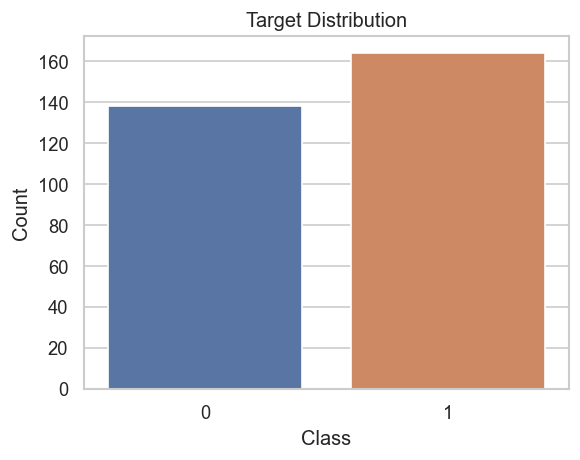

Cleaned target distribution:


target
1    164
0    138
Name: count, dtype: int64

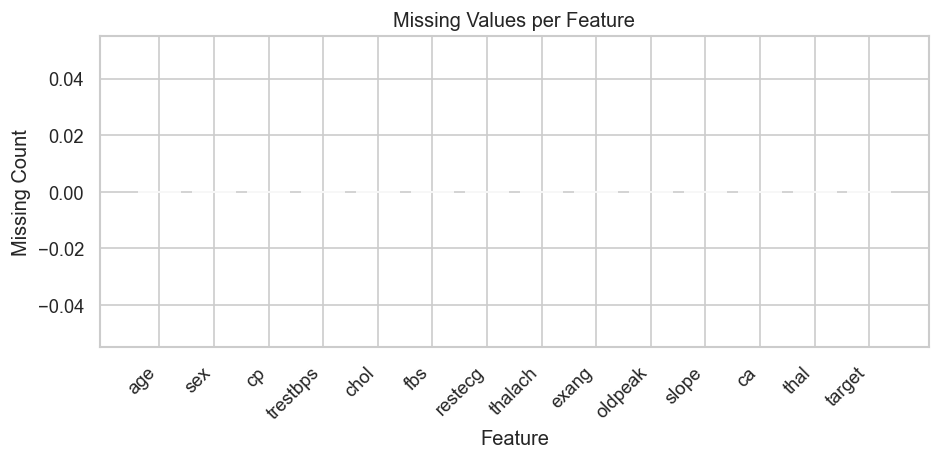

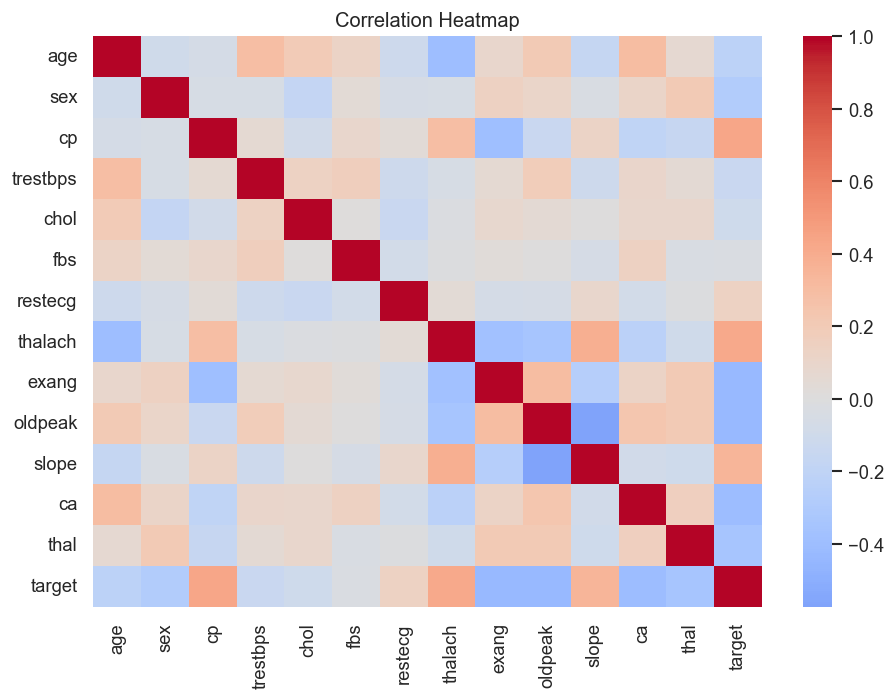

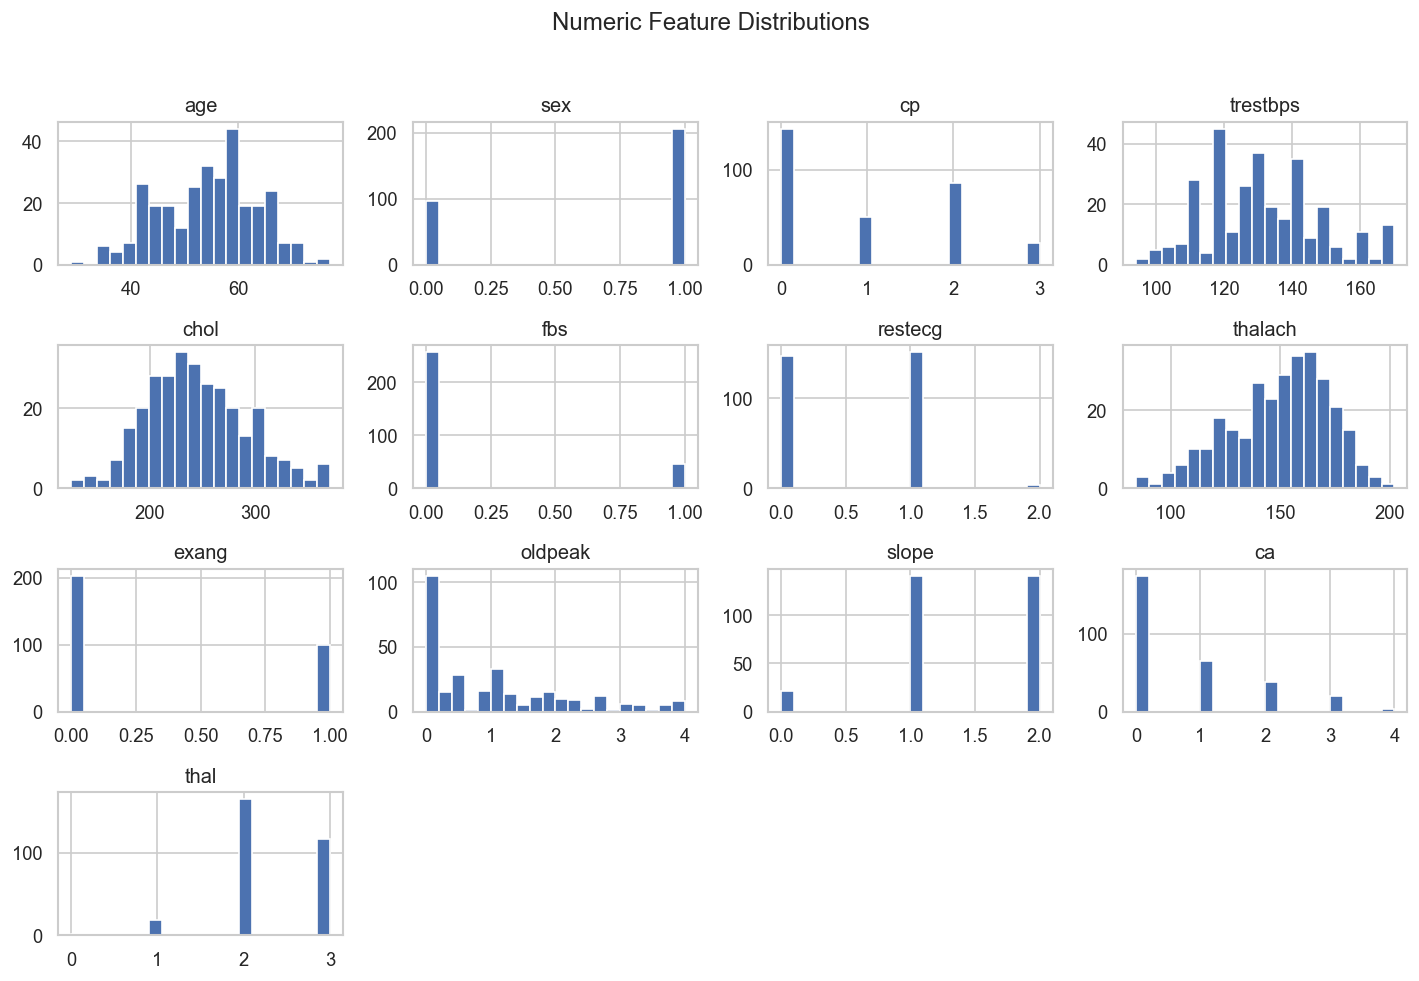

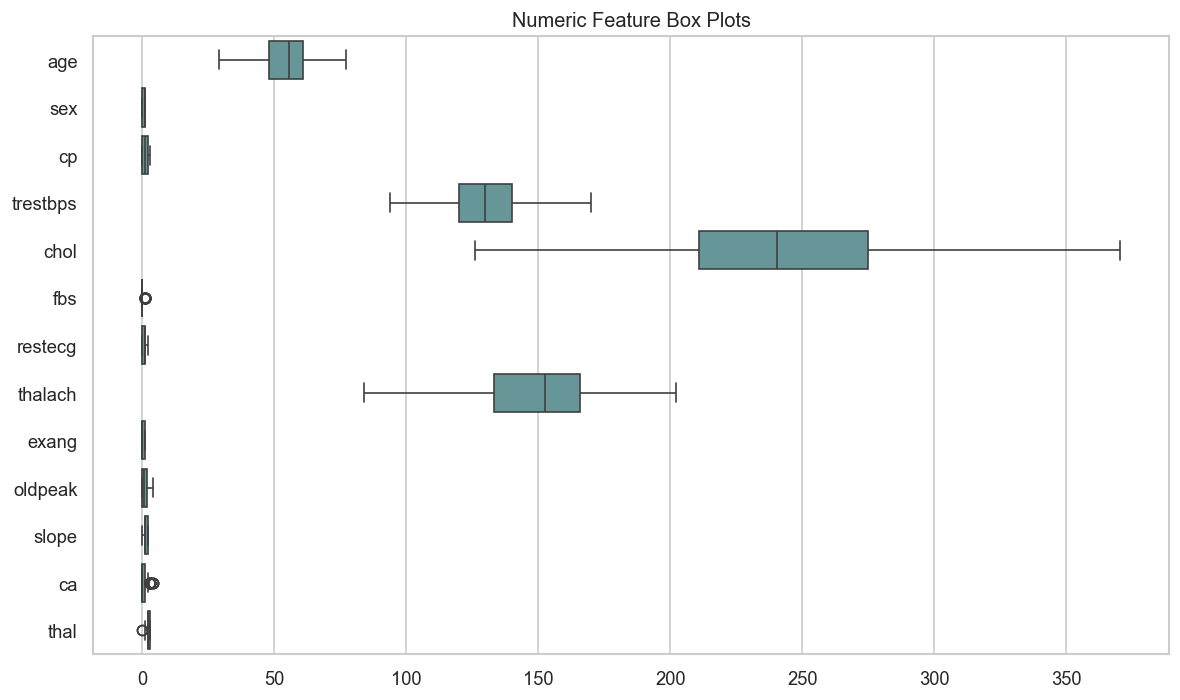

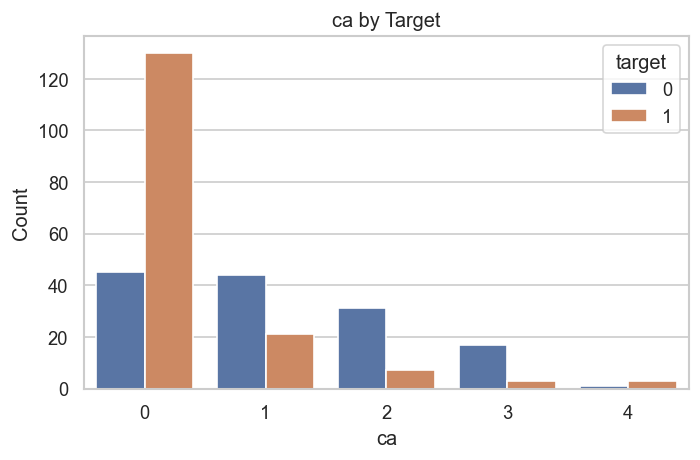

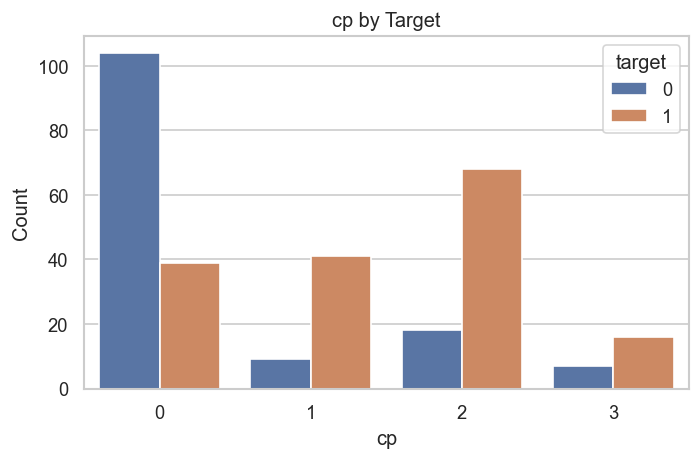

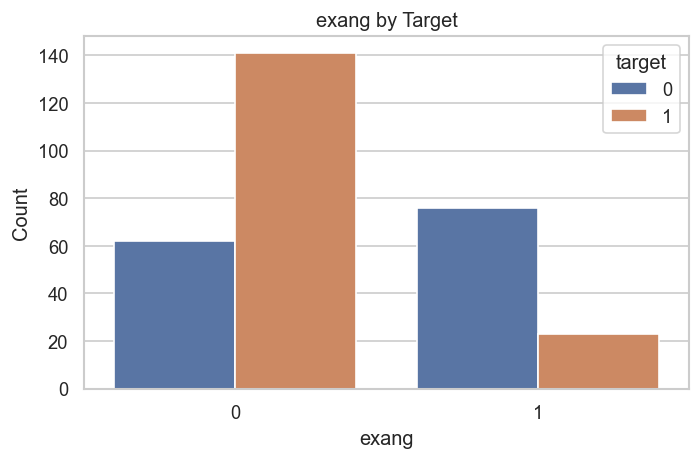

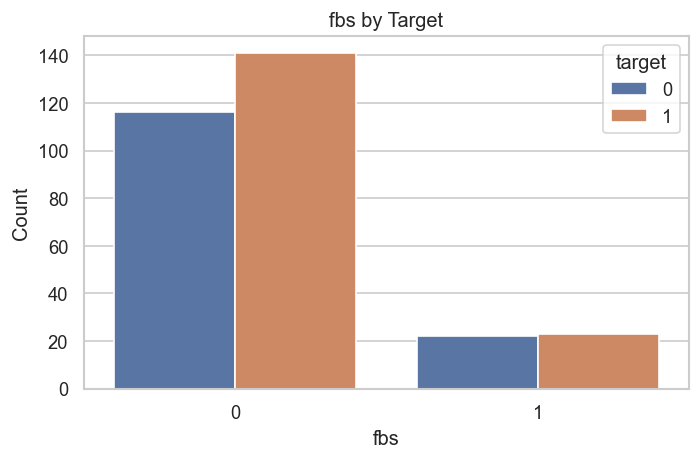

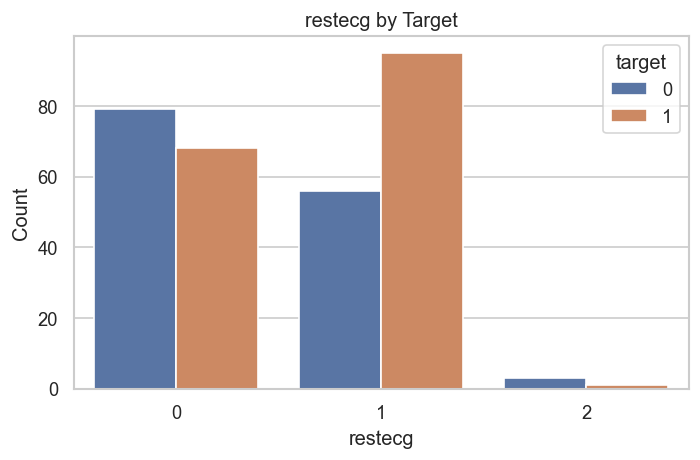

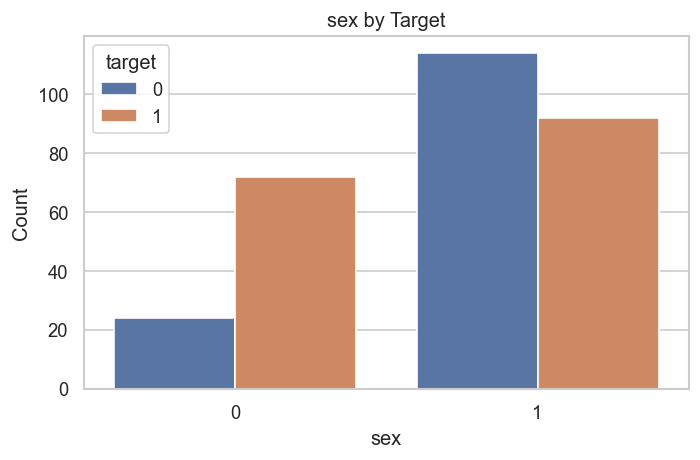

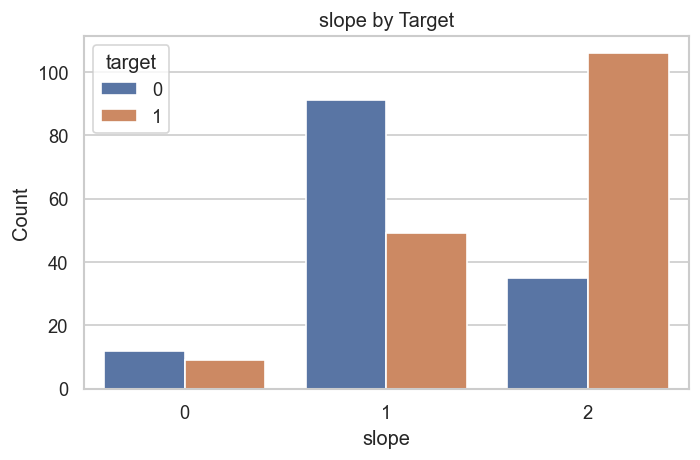

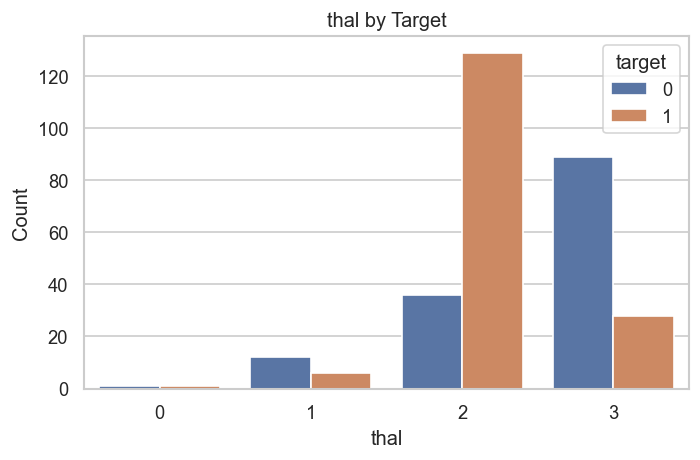

In [5]:
# Summary statistics
summ_df = df_clean.describe().T
missing_df = df_clean.isna().sum().reset_index()
missing_df.columns = ["Feature", "Missing Count"]

numeric_cols_eda = df_clean.select_dtypes(include=[np.number]).columns.tolist()
_, categorical_cols_eda, low_card_eda = detect_columns(df_clean, target_col)
categorical_cols_eda = sorted(set(categorical_cols_eda + low_card_eda))

numeric_cols_plot = [col for col in numeric_cols_eda if col != target_col]

display(summ_df)
display(missing_df)

# Target distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=target_col, data=df_clean, palette="deep")
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

clean_target_counts = df_clean[target_col].value_counts()
print("Cleaned target distribution:")
display(clean_target_counts)

# Missing values per feature
plt.figure(figsize=(8, 4))
plt.bar(missing_df["Feature"], missing_df["Missing Count"], color="#9b2226")
plt.title("Missing Values per Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Correlation heatmap
if numeric_cols_eda:
    corr_df = df_clean[numeric_cols_eda].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# Numeric distributions
if numeric_cols_plot:
    df_clean[numeric_cols_plot].hist(bins=20, figsize=(12, 8))
    plt.suptitle("Numeric Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.show()

# Box plots for numeric features
if numeric_cols_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean[numeric_cols_plot], orient="h", color="#5f9ea0")
    plt.title("Numeric Feature Box Plots")
    plt.tight_layout()
    plt.show()

# Categorical feature counts by target
for col in categorical_cols_eda:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_clean, x=col, hue=target_col, palette="deep")
    plt.title(f"{col} by Target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# Feature Encoding & Scaling


**Explanation:** Define fixed preprocessing settings to keep experiments reproducible. Build a column-wise pipeline that imputes, encodes, scales, and applies IQR clipping inside the pipeline so thresholds are fit on the training data within each CV fold/holdout split. Build a reusable pipeline constructor and preview the processed feature matrix to verify transformations.


In [6]:
MISSING_STRATEGY = "Impute"
OUTLIER_METHOD = "IQR Clip"
SCALE_METHOD = "StandardScaler"
ENABLE_FEATURE_SELECTION = False
K_FEATURES = 20


class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = X.columns.to_numpy()
            X_df = X
        else:
            self.feature_names_in_ = None
            X_df = pd.DataFrame(X)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_clipped = X_df.clip(self.lower_bounds_, self.upper_bounds_, axis=1)
        return X_clipped.values

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if self.feature_names_in_ is not None:
            return np.asarray(self.feature_names_in_, dtype=object)
        return np.asarray([f"x{i}" for i in range(len(self.lower_bounds_))], dtype=object)


def build_preprocessor(df, target_col):
    numeric_cols, categorical_cols, low_card = detect_columns(df, target_col)
    selected_cats = sorted(set(categorical_cols + low_card))

    num_cols = [c for c in df.columns if c in numeric_cols and c not in selected_cats and c != target_col]
    cat_cols = [c for c in df.columns if c in selected_cats and c != target_col]

    num_steps = []
    if MISSING_STRATEGY == "Impute":
        num_steps.append(("imputer", SimpleImputer(strategy="median")))
    if OUTLIER_METHOD == "IQR Clip":
        num_steps.append(("outlier", IQRClipper()))
    if SCALE_METHOD == "StandardScaler":
        num_steps.append(("scaler", StandardScaler()))
    elif SCALE_METHOD == "MinMaxScaler":
        num_steps.append(("scaler", MinMaxScaler()))

    if not num_steps:
        num_steps = [("passthrough", "passthrough")]

    cat_steps = []
    if MISSING_STRATEGY == "Impute":
        cat_steps.append(("imputer", SimpleImputer(strategy="most_frequent")))
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)
    cat_steps.append(("onehot", onehot))

    numeric_transformer = Pipeline(steps=num_steps)
    categorical_transformer = Pipeline(steps=cat_steps)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop",
    )

    return preprocessor


def build_pipeline(model, df, target_col):
    preprocessor = build_preprocessor(df, target_col)
    steps = [("preprocess", preprocessor)]

    if ENABLE_FEATURE_SELECTION:
        steps.append(("selector", SelectKBest(mutual_info_classif, k=K_FEATURES)))

    steps.append(("model", model))
    return Pipeline(steps)


X_tmp = df_base.drop(columns=[target_col])
preprocessor = build_preprocessor(df_base, target_col)
X_processed = preprocessor.fit_transform(X_tmp)
feature_names = preprocessor.get_feature_names_out()
processed_df = pd.DataFrame(X_processed, columns=feature_names)
processed_df[target_col] = df_base[target_col].reset_index(drop=True)

print("Processed shape:", processed_df.shape)
display(processed_df.head())


Processed shape: (302, 31)


,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,cat__sex_0,cat__sex_1,cat__cp_0,cat__cp_1,cat__cp_2,...,cat__ca_0,cat__ca_1,cat__ca_2,cat__ca_3,cat__ca_4,cat__thal_0,cat__thal_1,cat__thal_2,cat__thal_3,target
0,-0.267966,-0.377511,-0.704039,0.808993,-0.025091,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.157260,0.527318,-0.893880,0.237018,1.869266,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,1.724733,0.828927,-1.505591,-1.082925,1.418229,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.728383,1.009893,-0.893880,0.501006,-0.927166,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,0.839089,0.406674,1.025627,-1.918889,0.786777,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


# Train/Test Split & Cross-Validation Setup


**Explanation:** Create a stratified train/test split for a final holdout evaluation and define stratified k-fold CV for fair model comparison. Implement helper functions to compute consistent classification metrics, including AUC and PR AUC when probabilities are available. Add a short summarization helper to support discussion in later sections.


In [7]:
X = df_base.drop(columns=[target_col])
y = df_base[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


def evaluate_train_test(pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    n_classes = len(np.unique(y_test))
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        probas = pipeline.predict_proba(X_test)
        if n_classes > 2:
            y_prob = probas
        else:
            y_prob = probas[:, 1]
    else:
        y_prob = None

    avg_method = "macro" if n_classes > 2 else "binary"
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average=avg_method, zero_division=0),
        "Recall": recall_score(y_test, y_pred, average=avg_method, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average=avg_method, zero_division=0),
    }

    if y_prob is not None:
        if n_classes > 2:
            classes = np.unique(y_test)
            y_bin = label_binarize(y_test, classes=classes)
            try:
                metrics["AUC"] = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
            except Exception:
                metrics["AUC"] = np.nan
            try:
                metrics["PR AUC"] = average_precision_score(y_bin, y_prob, average="macro")
            except Exception:
                metrics["PR AUC"] = np.nan
        else:
            metrics["AUC"] = roc_auc_score(y_test, y_prob)
            metrics["PR AUC"] = average_precision_score(y_test, y_prob)
    else:
        metrics["AUC"] = np.nan
        metrics["PR AUC"] = np.nan

    cm = confusion_matrix(y_test, y_pred)
    return metrics, y_pred, pipeline, cm


def evaluate_cv(pipeline, X, y, cv):
    n_classes = len(np.unique(y))
    scoring = {"accuracy": "accuracy"}
    if n_classes > 2:
        scoring.update(
            {
                "precision": "precision_macro",
                "recall": "recall_macro",
                "f1": "f1_macro",
                "roc_auc": "roc_auc_ovr",
            }
        )
    else:
        scoring.update(
            {
                "precision": "precision",
                "recall": "recall",
                "f1": "f1",
                "roc_auc": "roc_auc",
                "pr_auc": "average_precision",
            }
        )
    scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)
    metrics = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1 Score": scores["test_f1"].mean(),
        "AUC": scores["test_roc_auc"].mean() if "test_roc_auc" in scores else np.nan,
        "PR AUC": scores["test_pr_auc"].mean() if "test_pr_auc" in scores else np.nan,
        "Train Accuracy": scores["train_accuracy"].mean(),
        "Train F1": scores["train_f1"].mean(),
    }
    return metrics


def summarize_results(df, rank_metric):
    if df.empty or rank_metric not in df.columns:
        return None
    best_row = df.loc[df[rank_metric].idxmax()]
    worst_row = df.loc[df[rank_metric].idxmin()]

    notes = []
    score_gap = best_row[rank_metric] - worst_row[rank_metric]
    if score_gap < 0.02:
        notes.append("Models perform similarly; metric gap is small.")
    else:
        notes.append(f"Best vs worst gap is {score_gap:.3f} on {rank_metric}.")

    if "Train F1" in best_row and "F1 Score" in best_row:
        gap = best_row["Train F1"] - best_row["F1 Score"]
        if gap > 0.05:
            notes.append("Best model shows signs of overfitting (train F1 notably higher).")
    if "Train F1" in worst_row and "F1 Score" in worst_row:
        gap = worst_row["Train F1"] - worst_row["F1 Score"]
        if gap < 0.01:
            notes.append("Worst model may be underfitting (train and test F1 both low).")

    summary = {
        "best": best_row["Model"],
        "worst": worst_row["Model"],
        "notes": notes,
    }
    return summary


Train shape: (241, 13)
Test shape: (61, 13)


# Non-Ensemble Models


**Explanation:** Define the non-ensemble baseline models and optional class imbalance handling. Initialize a results list to collect CV metrics. Create a helper that builds the preprocessing pipeline, runs CV, and records metrics uniformly.


In [8]:
HANDLE_IMBALANCE = False
class_weight = "balanced" if HANDLE_IMBALANCE else None

non_ensemble_models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=class_weight),
    "SVM (RBF)": SVC(probability=True, class_weight=class_weight),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=class_weight),
}

non_ensemble_results = []


def run_model_cv(model_name, model, results_list):
    pipeline = build_pipeline(model, df_base, target_col)
    metrics = evaluate_cv(pipeline, X, y, cv)
    metrics["Model"] = model_name
    results_list.append(metrics)
    return metrics


# Logistic Regression


**Explanation:** Evaluate Logistic Regression with the shared preprocessing and cross-validation setup. This provides a strong linear baseline for comparison. Metrics are displayed as a single-row table for clarity.


In [9]:
log_metrics = run_model_cv("Logistic Regression", non_ensemble_models["Logistic Regression"], non_ensemble_results)
display(pd.DataFrame([log_metrics]))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.857541,0.857077,0.889962,0.870709,0.917406,0.922947,0.87665,0.889236,Logistic Regression


# SVM


**Explanation:** Evaluate the RBF-kernel SVM with the same preprocessing and CV settings. This isolates the effect of a non-linear decision boundary. Record and display the metrics in the same format as other models.


In [10]:
svm_metrics = run_model_cv("SVM (RBF)", non_ensemble_models["SVM (RBF)"], non_ensemble_results)
display(pd.DataFrame([svm_metrics]))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.831257,0.828243,0.877652,0.8488,0.90897,0.921266,0.92716,0.934307,SVM (RBF)


# KNN


**Explanation:** Evaluate KNN under the same pipeline and cross-validation configuration. This provides an instance-based baseline and highlights sensitivity to feature scaling. Record and display the metrics.


In [11]:
knn_metrics = run_model_cv("KNN", non_ensemble_models["KNN"], non_ensemble_results)
display(pd.DataFrame([knn_metrics]))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.821475,0.826943,0.853788,0.838489,0.886447,0.862311,0.87915,0.890694,KNN


# Non-Ensemble Results & Discussion


**Explanation:** Run the remaining baseline models (Decision Tree and Dummy) to complete the non-ensemble set. Aggregate results, rank by F1 score, and generate a short summary. Fit the best baseline on the holdout split and show a confusion matrix for error analysis.


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.857541,0.857077,0.889962,0.870709,0.917406,0.922947,0.876650,0.889236,Logistic Regression
1,0.831257,0.828243,0.877652,0.848800,0.908970,0.921266,0.927160,0.934307,SVM (RBF)
2,0.821475,0.826943,0.853788,0.838489,0.886447,0.862311,0.879150,0.890694,KNN
3,0.728525,0.748631,0.756250,0.749617,0.726405,0.698525,1.000000,1.000000,Decision Tree
4,0.543060,0.543060,1.000000,0.703852,0.500000,0.543060,0.543047,0.703862,Dummy (Most Frequent)


{'best': 'Logistic Regression', 'worst': 'Dummy (Most Frequent)', 'notes': ['Best vs worst gap is 0.167 on F1 Score.', 'Worst model may be underfitting (train and test F1 both low).']}
Holdout metrics: {'Accuracy': 0.8360655737704918, 'Precision': 0.8484848484848485, 'Recall': 0.8484848484848485, 'F1 Score': 0.8484848484848485, 'AUC': 0.906926406926407, 'PR AUC': 0.9282794688682017}


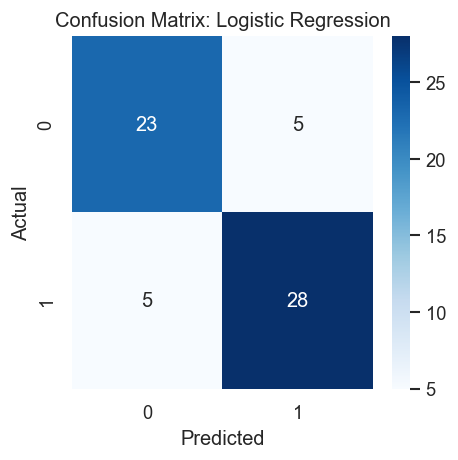

In [12]:
# Additional baselines
_ = run_model_cv("Decision Tree", non_ensemble_models["Decision Tree"], non_ensemble_results)
_ = run_model_cv("Dummy (Most Frequent)", non_ensemble_models["Dummy (Most Frequent)"], non_ensemble_results)

non_ensemble_df = pd.DataFrame(non_ensemble_results)
display(non_ensemble_df.sort_values(by="F1 Score", ascending=False))

summary = summarize_results(non_ensemble_df, "F1 Score")
print(summary)

best_name = summary["best"] if summary else None
if best_name and best_name in non_ensemble_models:
    pipeline = build_pipeline(non_ensemble_models[best_name], df_base, target_col)
    metrics, _, _, cm = evaluate_train_test(pipeline, X_train, X_test, y_train, y_test)
    print("Holdout metrics:", metrics)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {best_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# Ensemble Models


**Explanation:** Define ensemble models and compute class imbalance scaling for XGBoost when enabled. Keep parameters fixed to make baseline comparisons fair. Initialize a results list to store ensemble CV metrics.


In [13]:
if HANDLE_IMBALANCE and y.nunique() == 2:
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    scale_pos_weight = float(neg / max(pos, 1))
else:
    scale_pos_weight = 1.0

ensemble_models = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight=class_weight),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    ensemble_models["XGBoost"] = xgb.XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight
    )

ensemble_results = []


# Random Forest


**Explanation:** Evaluate Random Forest with the same preprocessing pipeline and CV design. This measures the benefit of bagging over a single tree. Display metrics for direct comparison.


In [14]:
rf_metrics = run_model_cv("Random Forest", ensemble_models["Random Forest"], ensemble_results)
display(pd.DataFrame([rf_metrics]))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.824699,0.838471,0.847727,0.838417,0.90611,0.911587,1.0,1.0,Random Forest


# Gradient Boosting


**Explanation:** Evaluate Gradient Boosting under the same pipeline and CV configuration. This captures the effect of sequential boosting on performance. Display metrics in the same tabular format.


In [15]:
gb_metrics = run_model_cv("Gradient Boosting", ensemble_models["Gradient Boosting"], ensemble_results)
display(pd.DataFrame([gb_metrics]))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.795027,0.796555,0.835417,0.812677,0.881763,0.897038,0.997517,0.997724,Gradient Boosting


# AdaBoost and XGBoost


**Explanation:** Evaluate AdaBoost and, if available, XGBoost with the same preprocessing and CV setup. This keeps comparisons consistent across boosted ensembles. Display each model result as a separate row.


In [16]:
metrics_list = []

# AdaBoost
ada_metrics = run_model_cv("AdaBoost", ensemble_models["AdaBoost"], ensemble_results)
metrics_list.append(ada_metrics)

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_metrics = run_model_cv("XGBoost", ensemble_models["XGBoost"], ensemble_results)
    metrics_list.append(xgb_metrics)

# Display as a single table
display(pd.DataFrame(metrics_list))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.818033,0.815263,0.859280,0.832691,0.886073,0.888571,0.898183,0.906799,AdaBoost
1,0.808251,0.818764,0.835417,0.823759,0.871667,0.880383,1.000000,1.000000,XGBoost


# Ensemble Models Evaluation

In this section, we define and evaluate a set of ensemble learning models: **Random Forest**, **Gradient Boosting**, **AdaBoost**, and **XGBoost** (if available). We automatically calculate the `scale_pos_weight` to handle potential class imbalance for XGBoost. Each model is evaluated using cross-validation, and the resulting metrics are aggregated into a single summary table for comparison.

In [17]:
# 1. Calculate scale_pos_weight for XGBoost to handle class imbalance if needed
if HANDLE_IMBALANCE and y.nunique() == 2:
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    scale_pos_weight = float(neg / max(pos, 1))
else:
    scale_pos_weight = 1.0

# 2. Define the dictionary of ensemble models
ensemble_models_map = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight=class_weight),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
}

# Add XGBoost conditionally
if XGBOOST_AVAILABLE:
    ensemble_models_map["XGBoost"] = xgb.XGBClassifier(
        eval_metric="logloss", 
        random_state=RANDOM_STATE, 
        scale_pos_weight=scale_pos_weight
    )

# 3. Iterate through models, train/eval, and collect results
local_ensemble_metrics = []

for model_name, model_inst in ensemble_models_map.items():
    # run_model_cv presumably updates the global 'ensemble_results' list and returns metrics
    metrics = run_model_cv(model_name, model_inst, ensemble_results)
    local_ensemble_metrics.append(metrics)

# 4. Display all results in a single DataFrame
display(pd.DataFrame(local_ensemble_metrics))


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model
0,0.824699,0.838471,0.847727,0.838417,0.906110,0.911587,1.000000,1.000000,Random Forest
1,0.795027,0.796555,0.835417,0.812677,0.881763,0.897038,0.997517,0.997724,Gradient Boosting
2,0.818033,0.815263,0.859280,0.832691,0.886073,0.888571,0.898183,0.906799,AdaBoost
3,0.808251,0.818764,0.835417,0.823759,0.871667,0.880383,1.000000,1.000000,XGBoost


# Hyperparameter Tuning (GridSearchCV / RandomizedSearchCV)


**Explanation:** Specify fixed hyperparameter grids and run tuning with CV on the training split for reproducibility. Store the best estimator for each model and record both parameters and the best CV score. Evaluate tuned models on the holdout test split to avoid optimistic bias. Report tuned results for non-ensemble and ensemble models.


In [18]:
TUNING_METHOD = "GridSearchCV"
NON_SCORING_METRIC = "f1"
ENSEMBLE_SCORING_METRIC = "f1"

non_param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
    },
    "SVM (RBF)": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11],
        "model__weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__criterion": ["gini", "entropy"],
    },
}

ensemble_param_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4],
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.5, 1.0, 1.5],
    },
}

if XGBOOST_AVAILABLE:
    ensemble_param_grids["XGBoost"] = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
    }


def tune_model(model_name, model, param_grid, scoring, results_list, model_store):
    pipeline = build_pipeline(model, df_base, target_col)
    if TUNING_METHOD == "GridSearchCV":
        search = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    else:
        search = RandomizedSearchCV(
            pipeline,
            param_grid,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            n_iter=10,
            random_state=RANDOM_STATE,
        )

    search.fit(X_train, y_train)
    best_est = search.best_estimator_
    model_store[model_name] = best_est

    metrics, _, _, _ = evaluate_train_test(best_est, X_train, X_test, y_train, y_test)
    metrics["Model"] = model_name
    metrics["Best Params"] = str(search.best_params_)
    metrics["CV Best Score"] = search.best_score_
    results_list.append(metrics)
    return metrics


# Tune non-ensemble models
m_tuned_non = {}
tuned_non_ensemble_results = []
for name, model in non_ensemble_models.items():
    if name.startswith("Dummy"):
        continue
    params = non_param_grids.get(name, {})
    _ = tune_model(name, model, params, NON_SCORING_METRIC, tuned_non_ensemble_results, m_tuned_non)

# Tune ensemble models
m_tuned_ensemble = {}
tuned_ensemble_results = []
for name, model in ensemble_models.items():
    params = ensemble_param_grids.get(name, {})
    _ = tune_model(name, model, params, ENSEMBLE_SCORING_METRIC, tuned_ensemble_results, m_tuned_ensemble)


print("Tuned non-ensemble results:")
display(pd.DataFrame(tuned_non_ensemble_results))

print("Tuned ensemble results:")
display(pd.DataFrame(tuned_ensemble_results))


Tuned non-ensemble results:


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Model,Best Params,CV Best Score
0,0.836066,0.848485,0.848485,0.848485,0.915584,0.933912,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.872034
1,0.786885,0.812500,0.787879,0.800000,0.882035,0.895405,SVM (RBF),"{'model__C': 1, 'model__gamma': 'scale'}",0.882248
2,0.819672,0.843750,0.818182,0.830769,0.878788,0.876963,KNN,"{'model__n_neighbors': 11, 'model__weights': '...",0.865299
3,0.721311,0.750000,0.727273,0.738462,0.829545,0.795846,Decision Tree,"{'model__criterion': 'entropy', 'model__max_de...",0.816208


Tuned ensemble results:


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Model,Best Params,CV Best Score
0,0.803279,0.818182,0.818182,0.818182,0.880952,0.895603,Random Forest,"{'model__max_depth': 10, 'model__min_samples_s...",0.883932
1,0.754098,0.781250,0.757576,0.769231,0.850649,0.877328,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.855829
2,0.786885,0.812500,0.787879,0.800000,0.886364,0.912250,AdaBoost,"{'model__learning_rate': 0.5, 'model__n_estima...",0.850602
3,0.770492,0.787879,0.787879,0.787879,0.850649,0.862414,XGBoost,"{'model__colsample_bytree': 0.8, 'model__learn...",0.854437


# Ensemble Results Before & After Tuning


**Explanation:** Compare baseline ensemble metrics against tuned ensemble metrics in a single table. This makes improvements and regressions visible per model. The side-by-side layout supports concise reporting.


In [19]:
ensemble_df = pd.DataFrame(ensemble_results)
tuned_ensemble_df = pd.DataFrame(tuned_ensemble_results)

metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "PR AUC"]


def build_before_after_table(before_df, after_df, metric_cols):
    if before_df.empty or after_df.empty:
        return pd.DataFrame()
    before = before_df[["Model"] + metric_cols]
    after = after_df[["Model"] + metric_cols]
    merged = before.merge(after, on="Model", how="inner", suffixes=(" (Before)", " (After)"))
    return merged

comparison_df = build_before_after_table(ensemble_df, tuned_ensemble_df, metric_cols)
display(comparison_df)


,Model,Accuracy (Before),Precision (Before),Recall (Before),F1 Score (Before),AUC (Before),PR AUC (Before),Accuracy (After),Precision (After),Recall (After),F1 Score (After),AUC (After),PR AUC (After)
0,Random Forest,0.824699,0.838471,0.847727,0.838417,0.906110,0.911587,0.803279,0.818182,0.818182,0.818182,0.880952,0.895603
1,Gradient Boosting,0.795027,0.796555,0.835417,0.812677,0.881763,0.897038,0.754098,0.781250,0.757576,0.769231,0.850649,0.877328
2,AdaBoost,0.818033,0.815263,0.859280,0.832691,0.886073,0.888571,0.786885,0.812500,0.787879,0.800000,0.886364,0.912250
3,XGBoost,0.808251,0.818764,0.835417,0.823759,0.871667,0.880383,0.770492,0.787879,0.787879,0.787879,0.850649,0.862414
4,Random Forest,0.824699,0.838471,0.847727,0.838417,0.906110,0.911587,0.803279,0.818182,0.818182,0.818182,0.880952,0.895603
5,Gradient Boosting,0.795027,0.796555,0.835417,0.812677,0.881763,0.897038,0.754098,0.781250,0.757576,0.769231,0.850649,0.877328
6,AdaBoost,0.818033,0.815263,0.859280,0.832691,0.886073,0.888571,0.786885,0.812500,0.787879,0.800000,0.886364,0.912250
7,XGBoost,0.808251,0.818764,0.835417,0.823759,0.871667,0.880383,0.770492,0.787879,0.787879,0.787879,0.850649,0.862414


# Feature Importance Analysis


**Explanation:** Compute feature importance for the each tuned ensemble model. Use model-based importances when available, otherwise fall back to permutation importance. Display the top features and visualize their relative contributions.


Feature importance: Random Forest


,Feature,Importance
7,cat__cp_0,0.105821
3,num__thalach,0.104254
28,cat__thal_2,0.079649
4,num__oldpeak,0.073930
21,cat__ca_0,0.072900
2,num__chol,0.065268
0,num__age,0.064644
29,cat__thal_3,0.059637
1,num__trestbps,0.056889
17,cat__exang_1,0.042990


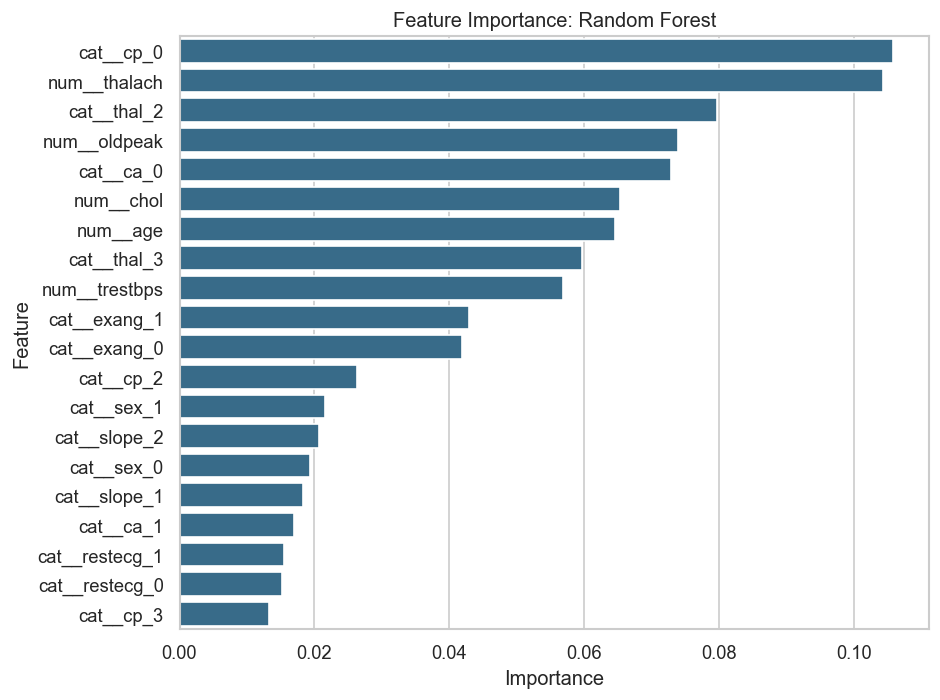

Feature importance: Gradient Boosting


,Feature,Importance
7,cat__cp_0,0.296111
28,cat__thal_2,0.144934
21,cat__ca_0,0.139146
3,num__thalach,0.082510
0,num__age,0.056947
4,num__oldpeak,0.050795
2,num__chol,0.043554
29,cat__thal_3,0.042832
17,cat__exang_1,0.025102
14,cat__restecg_1,0.021501


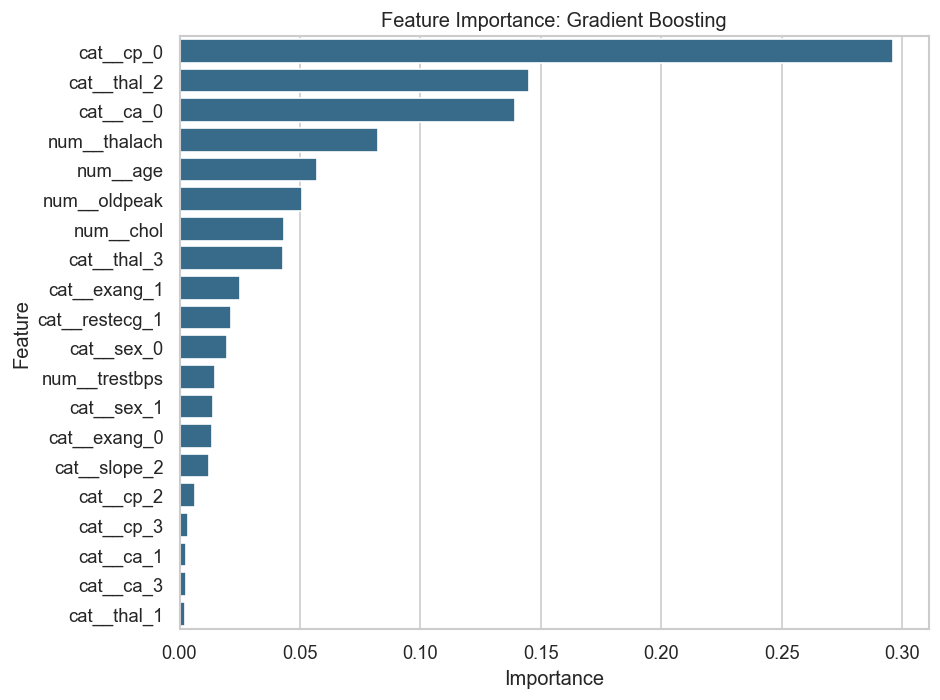

Feature importance: AdaBoost


,Feature,Importance
3,num__thalach,0.171784
4,num__oldpeak,0.118358
21,cat__ca_0,0.112810
7,cat__cp_0,0.104918
2,num__chol,0.085229
0,num__age,0.084495
5,cat__sex_0,0.074048
28,cat__thal_2,0.065399
1,num__trestbps,0.049159
16,cat__exang_0,0.036250


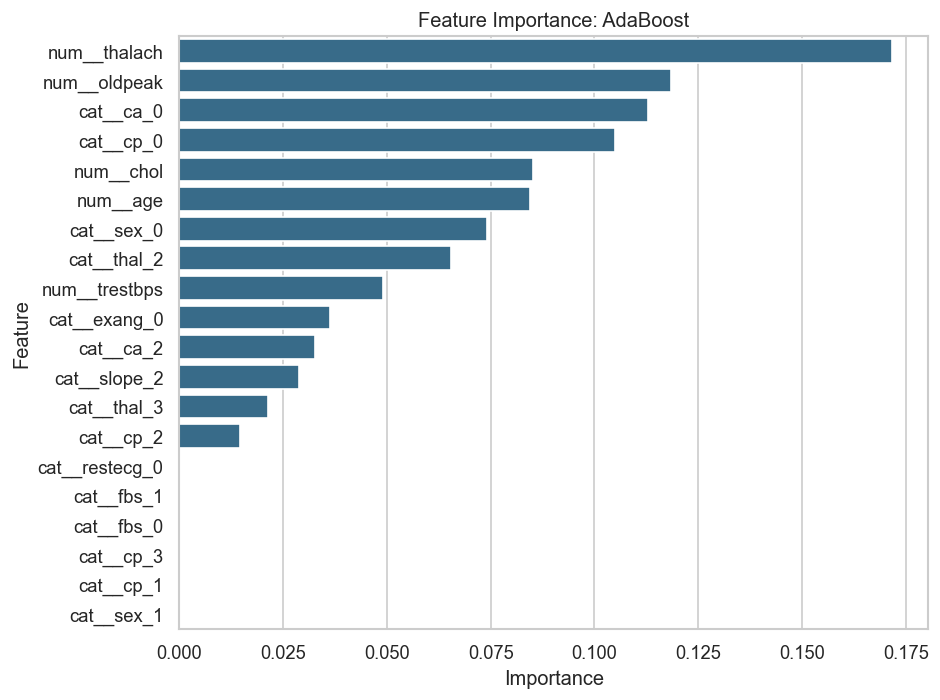

Feature importance: XGBoost


,Feature,Importance
7,cat__cp_0,0.180522
28,cat__thal_2,0.102301
29,cat__thal_3,0.076553
21,cat__ca_0,0.063731
17,cat__exang_1,0.062084
16,cat__exang_0,0.045090
10,cat__cp_3,0.039139
6,cat__sex_1,0.037683
5,cat__sex_0,0.035338
19,cat__slope_1,0.032620


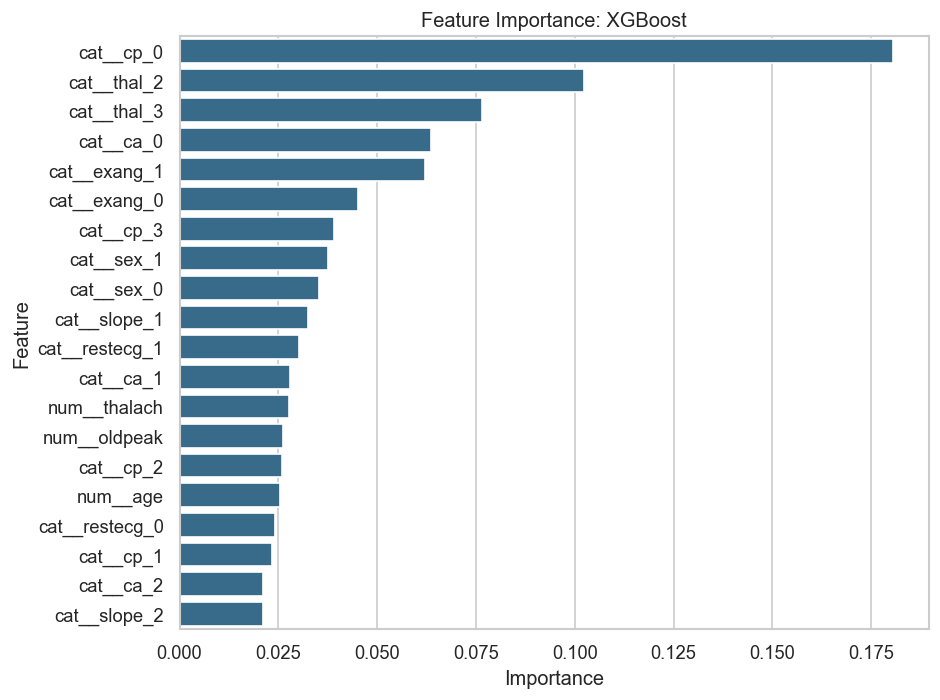

In [20]:
def compute_feature_importance(model_pipeline, df, target_col, top_n=20):
    preprocessor = model_pipeline.named_steps["preprocess"]
    feature_names = preprocessor.get_feature_names_out()

    if "selector" in model_pipeline.named_steps:
        support = model_pipeline.named_steps["selector"].get_support()
        feature_names = feature_names[support]

    model = model_pipeline.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    else:
        result = permutation_importance(
            model_pipeline,
            df.drop(columns=[target_col]),
            df[target_col],
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        fi_df = pd.DataFrame({"Feature": feature_names, "Importance": result.importances_mean})

    return fi_df.sort_values(by="Importance", ascending=False).head(top_n)


tuned_ensemble_df = pd.DataFrame(tuned_ensemble_results)
if tuned_ensemble_df.empty:
    print("No tuned ensemble models available for feature importance.")
else:
    for model_name in tuned_ensemble_df["Model"]:
        model_pipeline = m_tuned_ensemble.get(model_name)
        if model_pipeline is None:
            continue
        print(f"Feature importance: {model_name}")
        fi_df = compute_feature_importance(model_pipeline, df_base, target_col, top_n=20)
        display(fi_df)

        plt.figure(figsize=(8, 6))
        sns.barplot(data=fi_df, x="Importance", y="Feature", color="#2a6f97")
        plt.title(f"Feature Importance: {model_name}")
        plt.tight_layout()
        plt.show()


# Optional SHAP Analysis


**Explanation:** If SHAP is installed, compute SHAP values for the each tuned ensemble model using a sampled subset for efficiency. Generate both summary and bar plots to interpret global feature effects. This provides a model-agnostic explanation layer for the final report.


Top SHAP drivers: Random Forest


,Feature,Mean |SHAP|
0,num__age,0.021316
1,num__trestbps,0.021316


SHAP summary: Random Forest


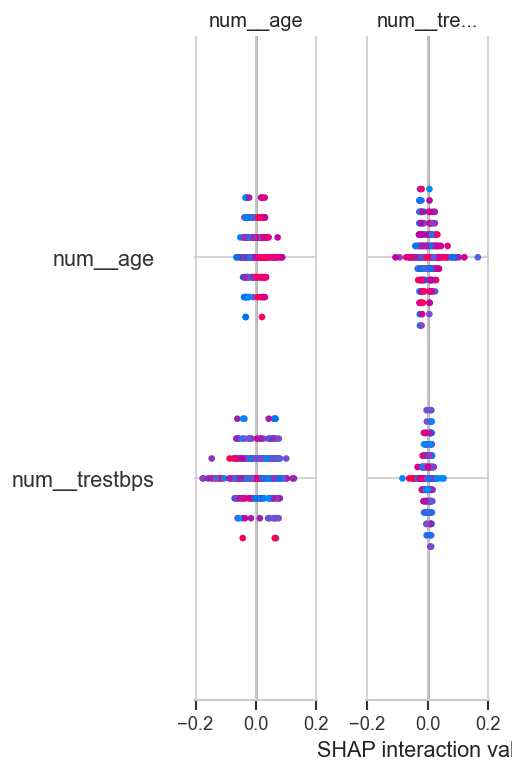

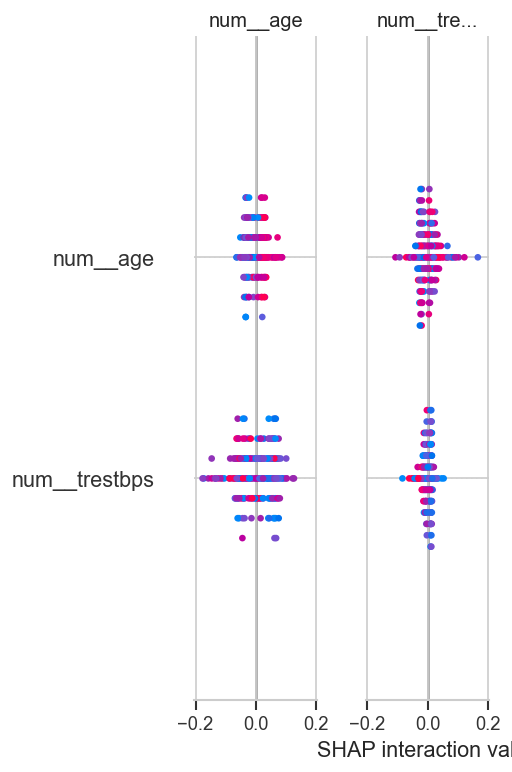

Top SHAP drivers: Gradient Boosting


,Feature,Mean |SHAP|
0,cat__ca_0,0.847864
1,cat__cp_0,0.700606
2,cat__thal_2,0.449004
3,num__oldpeak,0.386364
4,cat__thal_3,0.231363
5,num__chol,0.230707
6,cat__slope_1,0.208630
7,num__thalach,0.208541
8,num__age,0.192717
9,cat__sex_0,0.185191


SHAP summary: Gradient Boosting


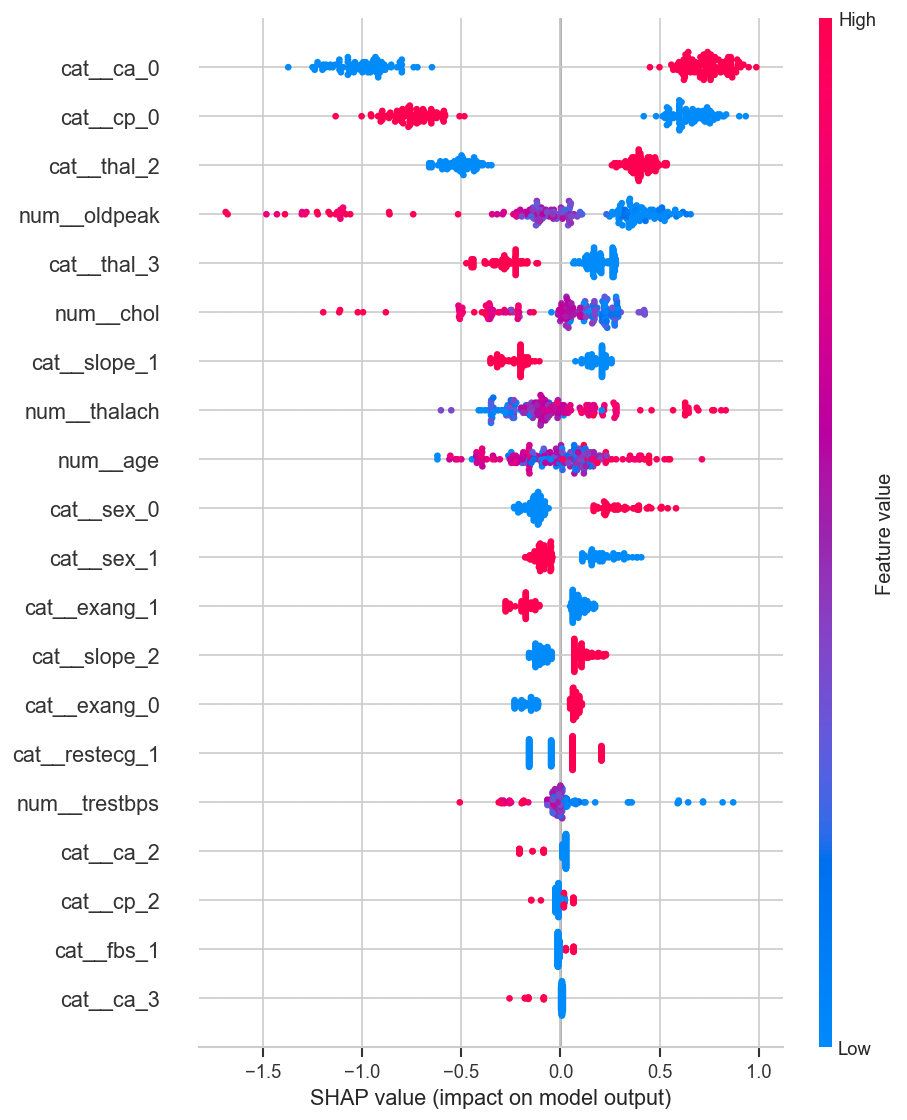

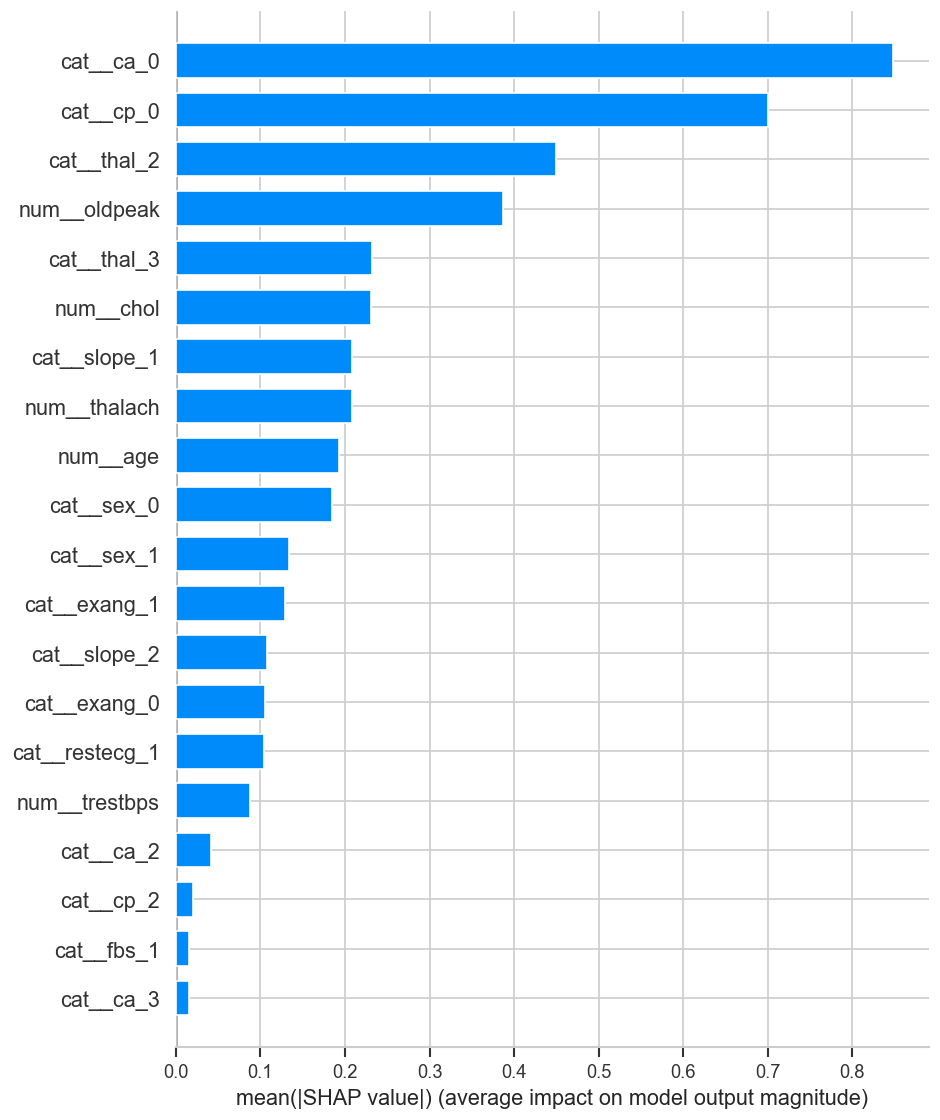

Skipping SHAP for AdaBoost: TreeExplainer not supported for this model.
Top SHAP drivers: XGBoost


,Feature,Mean |SHAP|
0,cat__ca_0,0.901131
1,cat__cp_0,0.844736
2,num__oldpeak,0.527337
3,cat__thal_2,0.519072
4,cat__sex_0,0.412040
5,num__age,0.400310
6,cat__thal_3,0.378145
7,num__chol,0.340706
8,num__thalach,0.331903
9,cat__slope_1,0.279928


SHAP summary: XGBoost


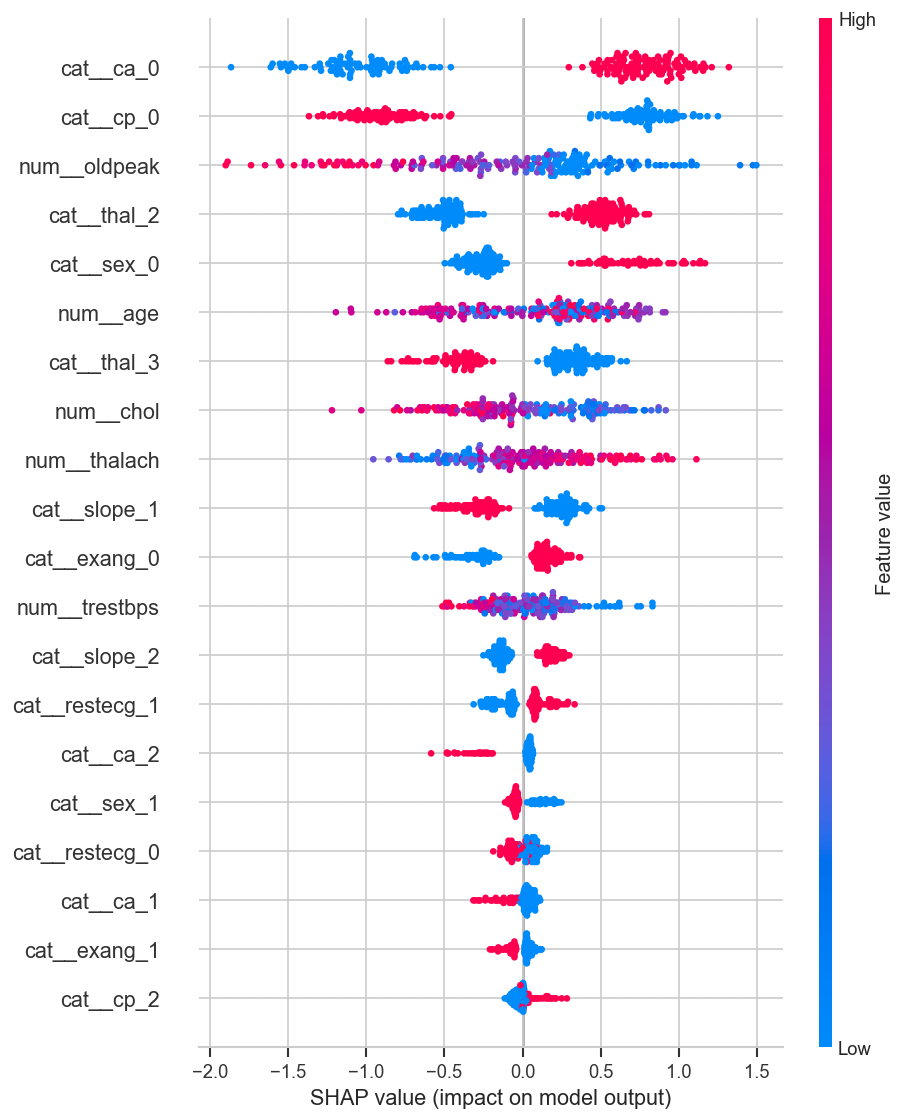

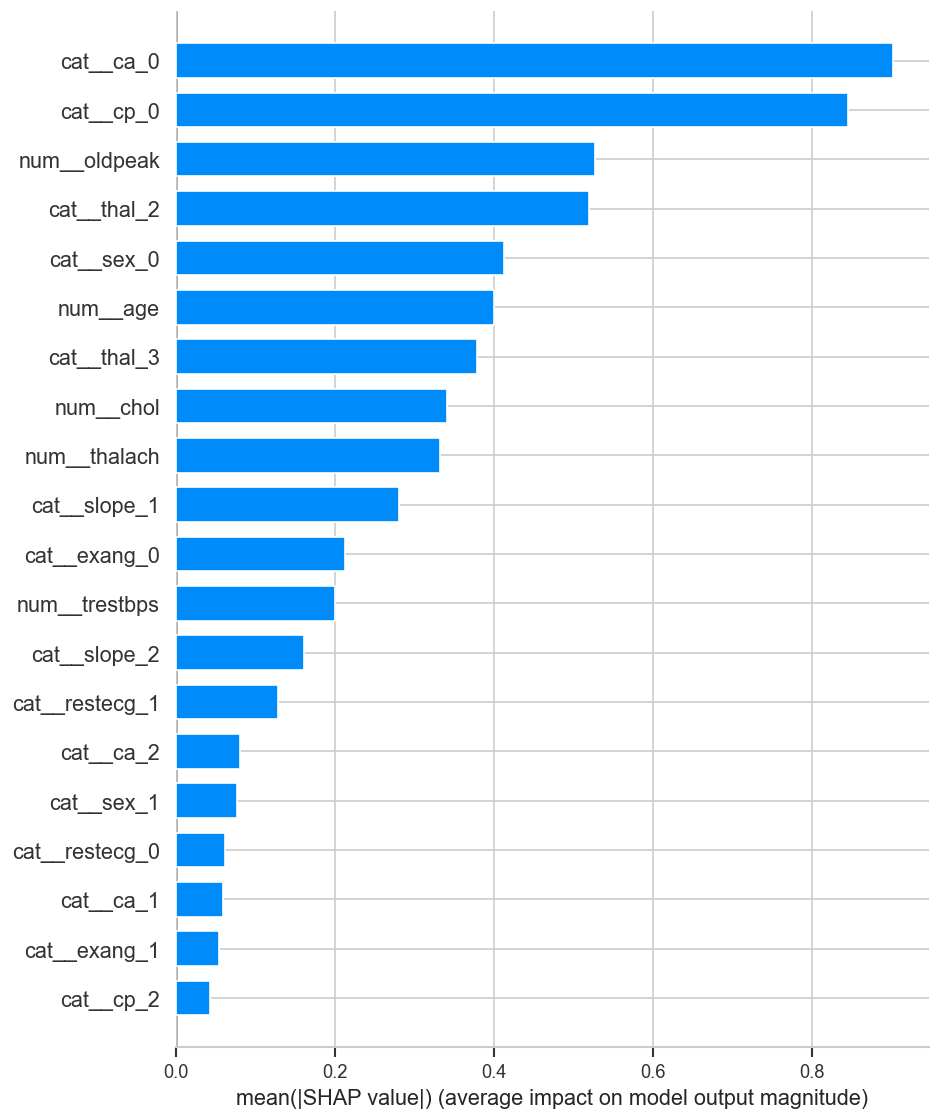

In [21]:
if SHAP_AVAILABLE and not tuned_ensemble_df.empty:
    try:
        import sys
        for stream in (sys.stdout, sys.stderr):
            if hasattr(stream, "reconfigure"):
                stream.reconfigure(encoding="utf-8", errors="replace")
    except Exception:
        pass

    def safe_print(message):
        try:
            print(message)
        except UnicodeEncodeError:
            safe = str(message).encode("ascii", "backslashreplace").decode("ascii")
            print(safe)

    try:
        import tqdm
        _tqdm = tqdm.tqdm
        def _safe_tqdm(*args, **kwargs):
            kwargs.setdefault("ascii", True)
            kwargs.setdefault("disable", True)
            return _tqdm(*args, **kwargs)
        tqdm.tqdm = _safe_tqdm
        try:
            import tqdm.auto as tqdm_auto
            tqdm_auto.tqdm = _safe_tqdm
        except Exception:
            pass
    except Exception:
        pass

    X_sample = X.sample(min(200, len(X)), random_state=RANDOM_STATE)

    tree_model_types = (RandomForestClassifier, GradientBoostingClassifier)
    if XGBOOST_AVAILABLE:
        tree_model_types = tree_model_types + (xgb.XGBClassifier,)

    for model_name in tuned_ensemble_df["Model"]:
        model_pipeline = m_tuned_ensemble.get(model_name)
        if model_pipeline is None:
            continue

        model = model_pipeline.named_steps["model"]
        if not isinstance(model, tree_model_types):
            safe_print(f"Skipping SHAP for {model_name}: TreeExplainer not supported for this model.")
            continue

        model_pipeline.fit(X, y)
        preprocessor = model_pipeline.named_steps["preprocess"]

        X_transformed = preprocessor.transform(X_sample)
        feature_names = preprocessor.get_feature_names_out()

        if "selector" in model_pipeline.named_steps:
            selector = model_pipeline.named_steps["selector"]
            X_transformed = selector.transform(X_transformed)
            feature_names = feature_names[selector.get_support()]

        if hasattr(X_transformed, "toarray"):
            X_array = X_transformed.toarray()
        else:
            X_array = np.array(X_transformed)

        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_array)
        except Exception as exc:
            safe_print(f"TreeExplainer failed for {model_name}: {exc}")
            continue

        shap_array = shap_values[1] if isinstance(shap_values, list) else shap_values

        mean_abs = np.abs(shap_array)
        if mean_abs.ndim > 2:
            mean_abs = mean_abs.mean(axis=0)
        mean_abs = mean_abs.mean(axis=0)

        top_n = min(10, len(feature_names))
        top_idx = np.argsort(mean_abs)[::-1][:top_n]
        top_df = pd.DataFrame(
            {"Feature": np.array(feature_names)[top_idx], "Mean |SHAP|": mean_abs[top_idx]}
        )

        safe_print(f"Top SHAP drivers: {model_name}")
        display(top_df)

        safe_print(f"SHAP summary: {model_name}")
        shap.summary_plot(shap_array, X_array, feature_names=feature_names, show=False)
        plt.tight_layout()
        plt.show()

        shap.summary_plot(shap_array, X_array, feature_names=feature_names, plot_type="bar", show=False)
        plt.tight_layout()
        plt.show()
else:
    print("SHAP is not available or tuned models are missing.")


# Overall Comparison & Final Discussion


**Explanation:** Combine all baseline and tuned results into a single comparison table. Sort by F1 score to identify the strongest overall model. Produce a concise summary to support the final discussion.


In [22]:
all_results = pd.concat(
    [
        pd.DataFrame(non_ensemble_results),
        pd.DataFrame(ensemble_results),
        pd.DataFrame(tuned_non_ensemble_results),
        pd.DataFrame(tuned_ensemble_results),
    ],
    ignore_index=True,
)

all_results = all_results.drop_duplicates(subset=["Model", "Best Params"], keep="first")
all_results = all_results.sort_values(by="F1 Score", ascending=False)

display(all_results)

summary_all = summarize_results(all_results, "F1 Score")
print(summary_all)


,Accuracy,Precision,Recall,F1 Score,AUC,PR AUC,Train Accuracy,Train F1,Model,Best Params,CV Best Score
0,0.857541,0.857077,0.889962,0.870709,0.917406,0.922947,0.876650,0.889236,Logistic Regression,NaN,NaN
1,0.831257,0.828243,0.877652,0.848800,0.908970,0.921266,0.927160,0.934307,SVM (RBF),NaN,NaN
13,0.836066,0.848485,0.848485,0.848485,0.915584,0.933912,NaN,NaN,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.872034
2,0.821475,0.826943,0.853788,0.838489,0.886447,0.862311,0.879150,0.890694,KNN,NaN,NaN
5,0.824699,0.838471,0.847727,0.838417,0.906110,0.911587,1.000000,1.000000,Random Forest,NaN,NaN
7,0.818033,0.815263,0.859280,0.832691,0.886073,0.888571,0.898183,0.906799,AdaBoost,NaN,NaN
15,0.819672,0.843750,0.818182,0.830769,0.878788,0.876963,NaN,NaN,KNN,"{'model__n_neighbors': 11, 'model__weights': '...",0.865299
8,0.808251,0.818764,0.835417,0.823759,0.871667,0.880383,1.000000,1.000000,XGBoost,NaN,NaN
17,0.803279,0.818182,0.818182,0.818182,0.880952,0.895603,NaN,NaN,Random Forest,"{'model__max_depth': 10, 'model__min_samples_s...",0.883932
6,0.795027,0.796555,0.835417,0.812677,0.881763,0.897038,0.997517,0.997724,Gradient Boosting,NaN,NaN


{'best': 'Logistic Regression', 'worst': 'Dummy (Most Frequent)', 'notes': ['Best vs worst gap is 0.167 on F1 Score.', 'Worst model may be underfitting (train and test F1 both low).']}


# Conclusion & Future Work
- Ensemble models generally improve performance after tuning.
- Feature importance highlights the strongest clinical predictors.
- Future work: validate on external cohorts, explore calibration, and assess fairness across subgroups.
